In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Trial1/OFT_FP1.csv"
ts_path = "Trial1/timestamp1.csv"
eth_path = "Trial1/Raw data-OFT_photobleaching_cohort2_20260204-Trial     1.xlsx"

behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage",
    "smell-poop",
    "Hand_touch_mouse"
]

video_fps = 50.0  # EthoVision video frame rate
fp_fps = 50.0     # Fiber photometry overall rate (25 Hz per LED)

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)
# Keep LED 1 and 2 only
fp = fp[fp["LedState"].isin([1, 2])].copy()
# Normalize time to start at 0
fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# -------------------------------------------------
# 3. Load timestamp alignment (video start/stop)
# -------------------------------------------------
ts = pd.read_csv(ts_path)
video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])
video_stop  = float(ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"].iloc[0])

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 4. Load EthoVision data (header row 39)
# -------------------------------------------------
eth = pd.read_excel(eth_path, header=38)
eth = eth.dropna(axis=1, how="all")

# Identify the time column
time_col = next((c for c in eth.columns if "Time" in str(c)), None)
if time_col is None:
    eth["Time_s"] = np.arange(len(eth)) / video_fps
    time_col = "Time_s"
else:
    eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# Keep only specified behaviors that exist
beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
if not beh_cols:
    print("Available columns:", list(eth.columns))
    raise ValueError("None of the specified behavior columns found in EthoVision data!")

eth = eth[["Time_s"] + beh_cols].copy()

# -------------------------------------------------
# 5. Prepare ethogram data for plotting
# -------------------------------------------------
segments = []
for beh in beh_cols:
    mask = eth[beh] == 1
    if mask.sum() == 0:
        continue
    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"].values
    ends = eth.loc[diff == -1, "Time_s"].values
    if mask.iloc[0]:
        starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
    if mask.iloc[-1]:
        ends = np.append(ends, eth["Time_s"].iloc[-1])
    for s, e in zip(starts, ends):
        segments.append({
            "Behavior": beh,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

timeline = pd.DataFrame(segments).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

# -------------------------------------------------
# 6. Plot FP traces (LED 1 & 2 separately) + ethogram
# -------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1["G0"], color="tab:gray", linewidth=0.8)
axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1 (isosbestic)")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2["G0"], color="tab:green", linewidth=0.8)
axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
axes[1].set_title("Fiber Photometry: LED 2 (GCaMP)")
axes[1].grid(True)

# --- Ethogram (behaviors) ---
if not timeline.empty:
    behaviors = timeline["Behavior"].unique()
    colors = plt.cm.tab10.colors
    for i, beh in enumerate(behaviors):
        sub = timeline[timeline["Behavior"] == beh]
        for _, row in sub.iterrows():
            axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"],
                         color=colors[i % len(colors)], height=0.6)
    axes[2].set_yticks(range(len(behaviors)))
    axes[2].set_yticklabels(behaviors)
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Ethogram (Behavior Occurrence)")
    axes[2].invert_yaxis()

# --- Shared settings ---
axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()


In [ ]:
# # 1) Fit isosbestic with biexponential decay

# # --- Isosbestic 415: plot + biexponential (MATLAB 'exp2') ---
# from scipy.optimize import curve_fit

# # MATLAB: exp2 -> a*exp(b*x) + c*exp(d*x)
# def exp2(x, a, b, c, d):
#     return a * np.exp(b * x) + c * np.exp(d * x)

# # Select 415 / isosbestic samples (change to == 2 if needed)
# fp415 = fp[fp["LedState"] == 1].copy().sort_values("Time_video")

# # y = raw signal; temp_x = frame-index to mimic MATLAB's 'temp_x'
# y = fp415["G0"].to_numpy()
# temp_x = np.arange(y.size, dtype=float)

# # Fit biexponential to 415 using frame-index (robust initial guesses)
# #p0 = [y.ptp(), -1e-3, 0.5 * y.ptp(), -1e-4]
# amp = np.ptp(y)   # peak-to-peak = max - min
# p0 = [amp, -1e-3, 0.5 * amp, -1e-4]

# popt, _ = curve_fit(exp2, temp_x, y, p0=p0, maxfev=20000)

# # Evaluate fit at the same indices, plot against time for readability
# y_fit = exp2(temp_x, *popt)

# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp415["Time_video"], y, linewidth=0.8, label="415 (isosbestic) raw")
# ax.plot(fp415["Time_video"], y_fit, linewidth=1.2, label="biexponential fit (exp2)")
# ax.set_title("Isosbestic 415 with biexponential fit")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("G0")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()
# #

In [ ]:
# #
# # 2) Linearly scale that fit to the calcium dependent data (using Robust Fit)

# from sklearn.linear_model import HuberRegressor  # robust linear regression

# # -------------------------------------------------
# # Assume you already have from previous step:
# #   fp415      -> dataframe with LedState == 1 (isosbestic)
# #   temp_x     -> np.arange(...) used for fitting
# #   popt       -> fitted parameters from exp2
# # -------------------------------------------------

# # --- Get the calcium-dependent 470 channel ---
# fp470 = fp[fp["LedState"] == 2].copy().sort_values("Time_video")

# # Make sure the two have the same length or align by time if needed
# # (Here we simply interpolate the 415 fit to 470 sample times.)
# from scipy.interpolate import interp1d
# fit_func = lambda x: popt[0]*np.exp(popt[1]*x) + popt[2]*np.exp(popt[3]*x)

# # Map time to frame index (same as before)
# idx_from_time = interp1d(fp415["Time_video"], temp_x, kind="linear",
#                          fill_value="extrapolate", assume_sorted=True)
# x470_idx = idx_from_time(fp470["Time_video"])
# iso_fit_at_470 = fit_func(x470_idx)

# # --- Robust linear scaling: equivalent of MATLAB robustfit(...,'bisquare') ---
# huber = HuberRegressor()  # similar spirit to robustfit
# huber.fit(iso_fit_at_470.reshape(-1, 1), fp470["G0"].to_numpy())

# slope = float(huber.coef_[0])
# intercept = float(huber.intercept_)

# # MATLAB: FP.lin_fit = FP.fit1(temp_x)*FP.fit2(2)+FP.fit2(1)
# fp470["lin_fit"] = intercept + slope * iso_fit_at_470

# # --- Plot raw 470 and scaled isosbestic fit ---
# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp470["Time_video"], fp470["G0"], linewidth=0.8, label="470 nm raw (Ca-dependent)")
# ax.plot(fp470["Time_video"], fp470["lin_fit"], linewidth=1.2, label="Scaled 415 nm fit (robust)")
# ax.set_title("Scaled isosbestic fit to calcium-dependent 470 nm signal")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("G0")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()


In [ ]:
# #3) Divide your raw 470 data by the scaled fit (dF)

# # -------------------------------------------------
# # 3) Divide raw 470 data by the scaled fit (dF)
# # MATLAB:
# #   FP.data(:,4) = FP.data(:,2) ./ FP.lin_fit;
# #   plot(FP.data(:,4))
# # -------------------------------------------------

# # Compute normalized fluorescence (dF)
# fp470["dF"] = fp470["G0"] / fp470["lin_fit"]

# # --- Plot normalized F value ---
# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp470["Time_video"], fp470["dF"], linewidth=0.8, label="Normalized F (dF)")
# ax.set_title("Normalized 470 nm signal (dF = raw / scaled fit)")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("Normalized Fluorescence (a.u.)")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()


In [ ]:
# #4) Calculate dF/F (%)

# # -------------------------------------------------
# # 4) Calculate dF/F (%) 
# # MATLAB:
# #   FP.data(:,5) = 100 * (FP.data(:,2) - FP.lin_fit) ./ FP.lin_fit;
# #   plot(FP.data(:,5))
# # -------------------------------------------------

# # Compute dF/F (%) — relative fluorescence change
# fp470["dF_F_percent"] = 100 * (fp470["G0"] - fp470["lin_fit"]) / fp470["lin_fit"]

# # --- Plot dF/F (%) ---
# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp470["Time_video"], fp470["dF_F_percent"], linewidth=0.8, label="dF/F (%)")
# ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
# ax.set_title("ΔF/F (%) — scaled relative fluorescence")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("ΔF/F (%)")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()


In [ ]:
# # -------------------------------------------------
# # Peri-Event Plot for 'Investigate_LEGO' with colored traces
# # -------------------------------------------------
# import numpy as np
# import matplotlib.pyplot as plt

# # --- Parameters ---
# bl = 100            # samples before event (~2 s at 50 Hz)
# seg_dur = 200       # samples after event (~4 s)
# signal_col = "dF_F_percent"   # which signal to use

# # --- Effective frame rate ---
# fps = 1 / np.mean(np.diff(fp470["Time_video"]))
# print(f"Effective frame rate ≈ {fps:.2f} Hz")

# # --- Get timestamps for 'Investigate_LEGO' starts ---
# mask = eth["Investigate_LEGO"] == 1
# diffs = mask.astype(int).diff().fillna(0)
# starts = eth.loc[diffs == 1, "Time_s"].to_numpy()

# # --- Collect peri-event segments ---
# segments = []
# signal = fp470[signal_col].to_numpy()
# time_fp = fp470["Time_video"].to_numpy()

# for ev_time in starts:
#     temp_idx = np.searchsorted(time_fp, ev_time)
#     if temp_idx >= bl and (temp_idx + seg_dur) < len(signal):
#         seg = signal[temp_idx - bl : temp_idx + seg_dur]
#         seg = seg - np.mean(seg[:bl])  # baseline correction
#         segments.append(seg)

# if len(segments) == 0:
#     raise ValueError("No valid LEGO events found within boundaries.")

# ERF = np.column_stack(segments)
# ERF_time = np.linspace(-bl/fps, seg_dur/fps, ERF.shape[0])

# # --- Plot ---
# fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# # Colored individual traces (muted)
# colors = plt.cm.tab10(np.linspace(0, 1, ERF.shape[1]))
# for i, col in enumerate(colors):
#     ax.plot(ERF_time, ERF[:, i], color=col, alpha=0.3, linewidth=1)

# # Thick black mean trace
# ax.plot(ERF_time, np.mean(ERF, axis=1), color="black", linewidth=2.5, label="Mean")

# # Formatting
# ax.axvline(0, color="k", linestyle="--", linewidth=1)
# ax.set_title("Peri-Event Fluorescence (Investigate_LEGO)")
# ax.set_xlabel("Time Relative to Event Start (s)")
# ax.set_ylabel("ΔF/F (%), baseline-corrected")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()


In [ ]:
# # -------------------------------------------------
# # Peri-Event Plot for 'Investigate_cheerio'
# # -------------------------------------------------
# import numpy as np
# import matplotlib.pyplot as plt

# # --- Parameters ---
# bl = 100            # samples before event (~2 s at 50 Hz)
# seg_dur = 200       # samples after event (~4 s)
# signal_col = "dF_F_percent"   # which signal to use for peri-event analysis

# # --- Effective frame rate ---
# fps = 1 / np.mean(np.diff(fp470["Time_video"]))
# print(f"Effective frame rate ≈ {fps:.2f} Hz")

# # --- Get timestamps for 'Investigate_cheerio' starts ---
# mask = eth["Investigate_cheerio"] == 1
# diffs = mask.astype(int).diff().fillna(0)
# starts = eth.loc[diffs == 1, "Time_s"].to_numpy()

# # --- Collect peri-event segments ---
# segments = []
# signal = fp470[signal_col].to_numpy()
# time_fp = fp470["Time_video"].to_numpy()

# for ev_time in starts:
#     temp_idx = np.searchsorted(time_fp, ev_time)
#     if temp_idx >= bl and (temp_idx + seg_dur) < len(signal):
#         seg = signal[temp_idx - bl : temp_idx + seg_dur]
#         seg = seg - np.mean(seg[:bl])  # baseline correction
#         segments.append(seg)

# if len(segments) == 0:
#     raise ValueError("No valid 'Investigate_cheerio' events found within boundaries.")

# ERF = np.column_stack(segments)
# ERF_time = np.linspace(-bl/fps, seg_dur/fps, ERF.shape[0])

# # --- Plot ---
# fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# # Colored individual traces (distinct but faint)
# colors = plt.cm.tab10(np.linspace(0, 1, ERF.shape[1]))
# for i, col in enumerate(colors):
#     ax.plot(ERF_time, ERF[:, i], color=col, alpha=0.3, linewidth=1)

# # Thick black mean trace
# ax.plot(ERF_time, np.mean(ERF, axis=1), color="black", linewidth=2.5, label="Mean")

# # Formatting
# ax.axvline(0, color="k", linestyle="--", linewidth=1)
# ax.set_title("Peri-Event Fluorescence (Investigate_cheerio)")
# ax.set_xlabel("Time Relative to Event Start (s)")
# ax.set_ylabel("ΔF/F (%), baseline-corrected")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()


# Trial 2

In [ ]:
# Trial 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Trial3/OFT_FP2.csv"
ts_path = "Trial3/timestamp0.csv"
eth_path = "Trial3/Raw data-OFT_photobleaching_cohort2_20260204-Trial     3.xlsx"

behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage",
    "smell-poop",
    "Hand_touch_mouse"
]

video_fps = 50.0  # EthoVision video frame rate
fp_fps = 50.0     # Fiber photometry overall rate (25 Hz per LED)

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)
# Keep LED 1 and 2 only
fp = fp[fp["LedState"].isin([1, 2])].copy()
# Normalize time to start at 0
fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# -------------------------------------------------
# 3. Load timestamp alignment (video start/stop)
# -------------------------------------------------
ts = pd.read_csv(ts_path)
video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])
video_stop  = float(ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"].iloc[0])

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 4. Load EthoVision data (header row 39)
# -------------------------------------------------
eth = pd.read_excel(eth_path, header=38)
eth = eth.dropna(axis=1, how="all")

# Identify the time column
time_col = next((c for c in eth.columns if "Time" in str(c)), None)
if time_col is None:
    eth["Time_s"] = np.arange(len(eth)) / video_fps
    time_col = "Time_s"
else:
    eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# Keep only specified behaviors that exist
beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
if not beh_cols:
    print("Available columns:", list(eth.columns))
    raise ValueError("None of the specified behavior columns found in EthoVision data!")

eth = eth[["Time_s"] + beh_cols].copy()

# -------------------------------------------------
# 5. Prepare ethogram data for plotting
# -------------------------------------------------
segments = []
for beh in beh_cols:
    mask = eth[beh] == 1
    if mask.sum() == 0:
        continue
    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"].values
    ends = eth.loc[diff == -1, "Time_s"].values
    if mask.iloc[0]:
        starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
    if mask.iloc[-1]:
        ends = np.append(ends, eth["Time_s"].iloc[-1])
    for s, e in zip(starts, ends):
        segments.append({
            "Behavior": beh,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

timeline = pd.DataFrame(segments).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

# -------------------------------------------------
# 6. Plot FP traces (LED 1 & 2 separately) + ethogram
# -------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1["G0"], color="tab:gray", linewidth=0.8)
axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1 (isosbestic)")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2["G0"], color="tab:green", linewidth=0.8)
axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
axes[1].set_title("Fiber Photometry: LED 2 (GCaMP)")
axes[1].grid(True)

# --- Ethogram (behaviors) ---
if not timeline.empty:
    behaviors = timeline["Behavior"].unique()
    colors = plt.cm.tab10.colors
    for i, beh in enumerate(behaviors):
        sub = timeline[timeline["Behavior"] == beh]
        for _, row in sub.iterrows():
            axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"],
                         color=colors[i % len(colors)], height=0.6)
    axes[2].set_yticks(range(len(behaviors)))
    axes[2].set_yticklabels(behaviors)
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Ethogram (Behavior Occurrence)")
    axes[2].invert_yaxis()

# --- Shared settings ---
axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()


In [ ]:
# # photobleaching correction

# # 1) Fit isosbestic with biexponential decay

# # --- Isosbestic 415: plot + biexponential (MATLAB 'exp2') ---
# from scipy.optimize import curve_fit

# # MATLAB: exp2 -> a*exp(b*x) + c*exp(d*x)
# def exp2(x, a, b, c, d):
#     return a * np.exp(b * x) + c * np.exp(d * x)

# # Select 415 / isosbestic samples (change to == 2 if needed)
# fp415 = fp[fp["LedState"] == 1].copy().sort_values("Time_video")

# # y = raw signal; temp_x = frame-index to mimic MATLAB's 'temp_x'
# y = fp415["G0"].to_numpy()
# temp_x = np.arange(y.size, dtype=float)

# # Fit biexponential to 415 using frame-index (robust initial guesses)
# p0 = [y.ptp(), -1e-3, 0.5 * y.ptp(), -1e-4]
# popt, _ = curve_fit(exp2, temp_x, y, p0=p0, maxfev=20000)

# # Evaluate fit at the same indices, plot against time for readability
# y_fit = exp2(temp_x, *popt)

# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp415["Time_video"], y, linewidth=0.8, label="415 (isosbestic) raw")
# ax.plot(fp415["Time_video"], y_fit, linewidth=1.2, label="biexponential fit (exp2)")
# ax.set_title("Isosbestic 415 with biexponential fit")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("G0")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()
# #
# #
# # 2) Linearly scale that fit to the calcium dependent data (using Robust Fit)

# from sklearn.linear_model import HuberRegressor  # robust linear regression

# # -------------------------------------------------
# # Assume you already have from previous step:
# #   fp415      -> dataframe with LedState == 1 (isosbestic)
# #   temp_x     -> np.arange(...) used for fitting
# #   popt       -> fitted parameters from exp2
# # -------------------------------------------------

# # --- Get the calcium-dependent 470 channel ---
# fp470 = fp[fp["LedState"] == 2].copy().sort_values("Time_video")

# # Make sure the two have the same length or align by time if needed
# # (Here we simply interpolate the 415 fit to 470 sample times.)
# from scipy.interpolate import interp1d
# fit_func = lambda x: popt[0]*np.exp(popt[1]*x) + popt[2]*np.exp(popt[3]*x)

# # Map time to frame index (same as before)
# idx_from_time = interp1d(fp415["Time_video"], temp_x, kind="linear",
#                          fill_value="extrapolate", assume_sorted=True)
# x470_idx = idx_from_time(fp470["Time_video"])
# iso_fit_at_470 = fit_func(x470_idx)

# # --- Robust linear scaling: equivalent of MATLAB robustfit(...,'bisquare') ---
# huber = HuberRegressor()  # similar spirit to robustfit
# huber.fit(iso_fit_at_470.reshape(-1, 1), fp470["G0"].to_numpy())

# slope = float(huber.coef_[0])
# intercept = float(huber.intercept_)

# # MATLAB: FP.lin_fit = FP.fit1(temp_x)*FP.fit2(2)+FP.fit2(1)
# fp470["lin_fit"] = intercept + slope * iso_fit_at_470

# # --- Plot raw 470 and scaled isosbestic fit ---
# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp470["Time_video"], fp470["G0"], linewidth=0.8, label="470 nm raw (Ca-dependent)")
# ax.plot(fp470["Time_video"], fp470["lin_fit"], linewidth=1.2, label="Scaled 415 nm fit (robust)")
# ax.set_title("Scaled isosbestic fit to calcium-dependent 470 nm signal")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("G0")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()

# #3) Divide your raw 470 data by the scaled fit (dF)

# # -------------------------------------------------
# # 3) Divide raw 470 data by the scaled fit (dF)
# # MATLAB:
# #   FP.data(:,4) = FP.data(:,2) ./ FP.lin_fit;
# #   plot(FP.data(:,4))
# # -------------------------------------------------

# # Compute normalized fluorescence (dF)
# fp470["dF"] = fp470["G0"] / fp470["lin_fit"]

# # --- Plot normalized F value ---
# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp470["Time_video"], fp470["dF"], linewidth=0.8, label="Normalized F (dF)")
# ax.set_title("Normalized 470 nm signal (dF = raw / scaled fit)")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("Normalized Fluorescence (a.u.)")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()

# #4) Calculate dF/F (%)

# # -------------------------------------------------
# # 4) Calculate dF/F (%) 
# # MATLAB:
# #   FP.data(:,5) = 100 * (FP.data(:,2) - FP.lin_fit) ./ FP.lin_fit;
# #   plot(FP.data(:,5))
# # -------------------------------------------------

# # Compute dF/F (%) — relative fluorescence change
# fp470["dF_F_percent"] = 100 * (fp470["G0"] - fp470["lin_fit"]) / fp470["lin_fit"]

# # --- Plot dF/F (%) ---
# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp470["Time_video"], fp470["dF_F_percent"], linewidth=0.8, label="dF/F (%)")
# ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
# ax.set_title("ΔF/F (%) — scaled relative fluorescence")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("ΔF/F (%)")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()



In [ ]:
# # -------------------------------------------------
# # Peri-Event Plot for 'Investigate_LEGO' with colored traces
# # -------------------------------------------------
# import numpy as np
# import matplotlib.pyplot as plt

# # --- Parameters ---
# bl = 100            # samples before event (~2 s at 50 Hz)
# seg_dur = 200       # samples after event (~4 s)
# signal_col = "dF_F_percent"   # which signal to use

# # --- Effective frame rate ---
# fps = 1 / np.mean(np.diff(fp470["Time_video"]))
# print(f"Effective frame rate ≈ {fps:.2f} Hz")

# # --- Get timestamps for 'Investigate_LEGO' starts ---
# mask = eth["Investigate_LEGO"] == 1
# diffs = mask.astype(int).diff().fillna(0)
# starts = eth.loc[diffs == 1, "Time_s"].to_numpy()

# # --- Collect peri-event segments ---
# segments = []
# signal = fp470[signal_col].to_numpy()
# time_fp = fp470["Time_video"].to_numpy()

# for ev_time in starts:
#     temp_idx = np.searchsorted(time_fp, ev_time)
#     if temp_idx >= bl and (temp_idx + seg_dur) < len(signal):
#         seg = signal[temp_idx - bl : temp_idx + seg_dur]
#         seg = seg - np.mean(seg[:bl])  # baseline correction
#         segments.append(seg)

# if len(segments) == 0:
#     raise ValueError("No valid LEGO events found within boundaries.")

# ERF = np.column_stack(segments)
# ERF_time = np.linspace(-bl/fps, seg_dur/fps, ERF.shape[0])

# # --- Plot ---
# fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# # Colored individual traces (muted)
# colors = plt.cm.tab10(np.linspace(0, 1, ERF.shape[1]))
# for i, col in enumerate(colors):
#     ax.plot(ERF_time, ERF[:, i], color=col, alpha=0.3, linewidth=1)

# # Thick black mean trace
# ax.plot(ERF_time, np.mean(ERF, axis=1), color="black", linewidth=2.5, label="Mean")

# # Formatting
# ax.axvline(0, color="k", linestyle="--", linewidth=1)
# ax.set_title("Peri-Event Fluorescence (Investigate_LEGO)")
# ax.set_xlabel("Time Relative to Event Start (s)")
# ax.set_ylabel("ΔF/F (%), baseline-corrected")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()


In [ ]:
# # -------------------------------------------------
# # Peri-Event Plot for 'Investigate_cheerio'
# # -------------------------------------------------
# import numpy as np
# import matplotlib.pyplot as plt

# # --- Parameters ---
# bl = 100            # samples before event (~2 s at 50 Hz)
# seg_dur = 200       # samples after event (~4 s)
# signal_col = "dF_F_percent"   # which signal to use for peri-event analysis

# # --- Effective frame rate ---
# fps = 1 / np.mean(np.diff(fp470["Time_video"]))
# print(f"Effective frame rate ≈ {fps:.2f} Hz")

# # --- Get timestamps for 'Investigate_cheerio' starts ---
# mask = eth["Investigate_cheerio"] == 1
# diffs = mask.astype(int).diff().fillna(0)
# starts = eth.loc[diffs == 1, "Time_s"].to_numpy()

# # --- Collect peri-event segments ---
# segments = []
# signal = fp470[signal_col].to_numpy()
# time_fp = fp470["Time_video"].to_numpy()

# for ev_time in starts:
#     temp_idx = np.searchsorted(time_fp, ev_time)
#     if temp_idx >= bl and (temp_idx + seg_dur) < len(signal):
#         seg = signal[temp_idx - bl : temp_idx + seg_dur]
#         seg = seg - np.mean(seg[:bl])  # baseline correction
#         segments.append(seg)

# if len(segments) == 0:
#     raise ValueError("No valid 'Investigate_cheerio' events found within boundaries.")

# ERF = np.column_stack(segments)
# ERF_time = np.linspace(-bl/fps, seg_dur/fps, ERF.shape[0])

# # --- Plot ---
# fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# # Colored individual traces (distinct but faint)
# colors = plt.cm.tab10(np.linspace(0, 1, ERF.shape[1]))
# for i, col in enumerate(colors):
#     ax.plot(ERF_time, ERF[:, i], color=col, alpha=0.3, linewidth=1)

# # Thick black mean trace
# ax.plot(ERF_time, np.mean(ERF, axis=1), color="black", linewidth=2.5, label="Mean")

# # Formatting
# ax.axvline(0, color="k", linestyle="--", linewidth=1)
# ax.set_title("Peri-Event Fluorescence (Investigate_cheerio)")
# ax.set_xlabel("Time Relative to Event Start (s)")
# ax.set_ylabel("ΔF/F (%), baseline-corrected")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()


In [ ]:
# Trial 6

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Trial6/OFT_FP4.csv"
ts_path = "Trial6/timestamp1.csv"
eth_path = "Trial6/Raw data-OFT_photobleaching_cohort2_20260204-Trial     6.xlsx"

behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage"
]

video_fps = 50.0
fp_fps = 50.0

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)

fp = fp[fp["LedState"].isin([1, 2])].copy()
fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# # -------------------------------------------------
# # 3. Load timestamp alignment (SAFE start/stop)
# # -------------------------------------------------
# ts = pd.read_csv(ts_path)

# true_ts = ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"]
# false_ts = ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"]

# if true_ts.empty:
#     raise ValueError("No TRUE DigitalIOState found — cannot determine video start.")

# video_start = float(true_ts.iloc[0])

# if not false_ts.empty:
#     video_stop = float(false_ts.iloc[0])
# else:
#     # FP stopped before video → use last timestamp available
#     video_stop = float(ts["SystemTimestamp"].iloc[-1])
#     print("WARNING: No FALSE DigitalIOState found — using last timestamp as video stop.")

# # Trim FP data to match video window
# fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
# fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 3. Load timestamp alignment (VIDEO START ONLY)
# -------------------------------------------------
ts = pd.read_csv(ts_path)

true_ts = ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"]

if true_ts.empty:
    raise ValueError("No TRUE DigitalIOState found — cannot determine video start.")

# Video starts when TTL goes TRUE
video_start = float(true_ts.iloc[0])

# Video ends when FP ends (FP stopped early)
video_stop = float(fp["SystemTimestamp"].max())

print(f"Video window used: {video_start:.3f} → {video_stop:.3f}")

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"] >= video_start].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start



# -------------------------------------------------
# 4. Load EthoVision data (header row 39)
# -------------------------------------------------
eth = pd.read_excel(eth_path, header=38)
eth = eth.dropna(axis=1, how="all")

# Identify time column
time_col = next((c for c in eth.columns if "Time" in str(c)), None)

if time_col is None:
    eth["Time_s"] = np.arange(len(eth)) / video_fps
else:
    eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# Keep only behaviors that exist
beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
if not beh_cols:
    print("Available columns:", list(eth.columns))
    raise ValueError("None of the specified behavior columns found in EthoVision data.")

eth = eth[["Time_s"] + beh_cols].copy()

# -------------------------------------------------
# 5. Prepare ethogram data for plotting
# -------------------------------------------------
segments = []

for beh in beh_cols:
    mask = eth[beh] == 1
    if mask.sum() == 0:
        continue

    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"].values
    ends = eth.loc[diff == -1, "Time_s"].values

    if mask.iloc[0]:
        starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
    if mask.iloc[-1]:
        ends = np.append(ends, eth["Time_s"].iloc[-1])

    for s, e in zip(starts, ends):
        segments.append({
            "Behavior": beh,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

timeline = (
    pd.DataFrame(segments)
    .sort_values(["Behavior", "Start_time_s"])
    .reset_index(drop=True)
)

# -------------------------------------------------
# 6. Plot FP traces + ethogram
# -------------------------------------------------
fig, axes = plt.subplots(
    3, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"height_ratios": [2, 2, 1]}
)

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1["G0"], linewidth=0.8)
axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2["G0"], linewidth=0.8)
axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
axes[1].set_title("Fiber Photometry: LED 2")
axes[1].grid(True)

# --- Ethogram ---
if not timeline.empty:
    behaviors = timeline["Behavior"].unique()
    colors = plt.cm.tab10.colors

    for i, beh in enumerate(behaviors):
        sub = timeline[timeline["Behavior"] == beh]
        for _, row in sub.iterrows():
            axes[2].barh(
                i,
                width=row["Duration_s"],
                left=row["Start_time_s"],
                height=0.6,
                color=colors[i % len(colors)]
            )

    axes[2].set_yticks(range(len(behaviors)))
    axes[2].set_yticklabels(behaviors)
    axes[2].invert_yaxis()
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Ethogram")

# --- Shared settings ---
axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()


In [ ]:
# #photo bleaching correction

# # photobleaching correction

# # 1) Fit isosbestic with biexponential decay

# # --- Isosbestic 415: plot + biexponential (MATLAB 'exp2') ---
# from scipy.optimize import curve_fit

# # MATLAB: exp2 -> a*exp(b*x) + c*exp(d*x)
# def exp2(x, a, b, c, d):
#     return a * np.exp(b * x) + c * np.exp(d * x)

# # Select 415 / isosbestic samples (change to == 2 if needed)
# fp415 = fp[fp["LedState"] == 1].copy().sort_values("Time_video")

# # y = raw signal; temp_x = frame-index to mimic MATLAB's 'temp_x'
# y = fp415["G0"].to_numpy()
# temp_x = np.arange(y.size, dtype=float)

# # Fit biexponential to 415 using frame-index (robust initial guesses)
# p0 = [y.ptp(), -1e-3, 0.5 * y.ptp(), -1e-4]
# popt, _ = curve_fit(exp2, temp_x, y, p0=p0, maxfev=20000)

# # Evaluate fit at the same indices, plot against time for readability
# y_fit = exp2(temp_x, *popt)

# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp415["Time_video"], y, linewidth=0.8, label="415 (isosbestic) raw")
# ax.plot(fp415["Time_video"], y_fit, linewidth=1.2, label="biexponential fit (exp2)")
# ax.set_title("Isosbestic 415 with biexponential fit")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("G0")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()
# #
# #
# # 2) Linearly scale that fit to the calcium dependent data (using Robust Fit)

# from sklearn.linear_model import HuberRegressor  # robust linear regression

# # -------------------------------------------------
# # Assume you already have from previous step:
# #   fp415      -> dataframe with LedState == 1 (isosbestic)
# #   temp_x     -> np.arange(...) used for fitting
# #   popt       -> fitted parameters from exp2
# # -------------------------------------------------

# # --- Get the calcium-dependent 470 channel ---
# fp470 = fp[fp["LedState"] == 2].copy().sort_values("Time_video")

# # Make sure the two have the same length or align by time if needed
# # (Here we simply interpolate the 415 fit to 470 sample times.)
# from scipy.interpolate import interp1d
# fit_func = lambda x: popt[0]*np.exp(popt[1]*x) + popt[2]*np.exp(popt[3]*x)

# # Map time to frame index (same as before)
# idx_from_time = interp1d(fp415["Time_video"], temp_x, kind="linear",
#                          fill_value="extrapolate", assume_sorted=True)
# x470_idx = idx_from_time(fp470["Time_video"])
# iso_fit_at_470 = fit_func(x470_idx)

# # --- Robust linear scaling: equivalent of MATLAB robustfit(...,'bisquare') ---
# huber = HuberRegressor()  # similar spirit to robustfit
# huber.fit(iso_fit_at_470.reshape(-1, 1), fp470["G0"].to_numpy())

# slope = float(huber.coef_[0])
# intercept = float(huber.intercept_)

# # MATLAB: FP.lin_fit = FP.fit1(temp_x)*FP.fit2(2)+FP.fit2(1)
# fp470["lin_fit"] = intercept + slope * iso_fit_at_470

# # --- Plot raw 470 and scaled isosbestic fit ---
# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp470["Time_video"], fp470["G0"], linewidth=0.8, label="470 nm raw (Ca-dependent)")
# ax.plot(fp470["Time_video"], fp470["lin_fit"], linewidth=1.2, label="Scaled 415 nm fit (robust)")
# ax.set_title("Scaled isosbestic fit to calcium-dependent 470 nm signal")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("G0")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()

# #3) Divide your raw 470 data by the scaled fit (dF)

# # -------------------------------------------------
# # 3) Divide raw 470 data by the scaled fit (dF)
# # MATLAB:
# #   FP.data(:,4) = FP.data(:,2) ./ FP.lin_fit;
# #   plot(FP.data(:,4))
# # -------------------------------------------------

# # Compute normalized fluorescence (dF)
# fp470["dF"] = fp470["G0"] / fp470["lin_fit"]

# # --- Plot normalized F value ---
# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp470["Time_video"], fp470["dF"], linewidth=0.8, label="Normalized F (dF)")
# ax.set_title("Normalized 470 nm signal (dF = raw / scaled fit)")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("Normalized Fluorescence (a.u.)")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()

# #4) Calculate dF/F (%)

# # -------------------------------------------------
# # 4) Calculate dF/F (%) 
# # MATLAB:
# #   FP.data(:,5) = 100 * (FP.data(:,2) - FP.lin_fit) ./ FP.lin_fit;
# #   plot(FP.data(:,5))
# # -------------------------------------------------

# # Compute dF/F (%) — relative fluorescence change
# fp470["dF_F_percent"] = 100 * (fp470["G0"] - fp470["lin_fit"]) / fp470["lin_fit"]

# # --- Plot dF/F (%) ---
# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp470["Time_video"], fp470["dF_F_percent"], linewidth=0.8, label="dF/F (%)")
# ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
# ax.set_title("ΔF/F (%) — scaled relative fluorescence")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("ΔF/F (%)")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()



In [ ]:
# # -------------------------------------------------
# # Peri-Event Plot for 'Investigate_LEGO' with colored traces
# # -------------------------------------------------
# import numpy as np
# import matplotlib.pyplot as plt

# # --- Parameters ---
# bl = 100            # samples before event (~2 s at 50 Hz)
# seg_dur = 200       # samples after event (~4 s)
# signal_col = "dF_F_percent"   # which signal to use

# # --- Effective frame rate ---
# fps = 1 / np.mean(np.diff(fp470["Time_video"]))
# print(f"Effective frame rate ≈ {fps:.2f} Hz")

# # --- Get timestamps for 'Investigate_LEGO' starts ---
# mask = eth["Investigate_LEGO"] == 1
# diffs = mask.astype(int).diff().fillna(0)
# starts = eth.loc[diffs == 1, "Time_s"].to_numpy()

# # --- Collect peri-event segments ---
# segments = []
# signal = fp470[signal_col].to_numpy()
# time_fp = fp470["Time_video"].to_numpy()

# for ev_time in starts:
#     temp_idx = np.searchsorted(time_fp, ev_time)
#     if temp_idx >= bl and (temp_idx + seg_dur) < len(signal):
#         seg = signal[temp_idx - bl : temp_idx + seg_dur]
#         seg = seg - np.mean(seg[:bl])  # baseline correction
#         segments.append(seg)

# if len(segments) == 0:
#     raise ValueError("No valid LEGO events found within boundaries.")

# ERF = np.column_stack(segments)
# ERF_time = np.linspace(-bl/fps, seg_dur/fps, ERF.shape[0])

# # --- Plot ---
# fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# # Colored individual traces (muted)
# colors = plt.cm.tab10(np.linspace(0, 1, ERF.shape[1]))
# for i, col in enumerate(colors):
#     ax.plot(ERF_time, ERF[:, i], color=col, alpha=0.3, linewidth=1)

# # Thick black mean trace
# ax.plot(ERF_time, np.mean(ERF, axis=1), color="black", linewidth=2.5, label="Mean")

# # Formatting
# ax.axvline(0, color="k", linestyle="--", linewidth=1)
# ax.set_title("Peri-Event Fluorescence (Investigate_LEGO)")
# ax.set_xlabel("Time Relative to Event Start (s)")
# ax.set_ylabel("ΔF/F (%), baseline-corrected")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()


In [ ]:
# # -------------------------------------------------
# # Peri-Event Plot for 'Investigate_cheerio'
# # -------------------------------------------------
# import numpy as np
# import matplotlib.pyplot as plt

# # --- Parameters ---
# bl = 100            # samples before event (~2 s at 50 Hz)
# seg_dur = 200       # samples after event (~4 s)
# signal_col = "dF_F_percent"   # which signal to use for peri-event analysis

# # --- Effective frame rate ---
# fps = 1 / np.mean(np.diff(fp470["Time_video"]))
# print(f"Effective frame rate ≈ {fps:.2f} Hz")

# # --- Get timestamps for 'Investigate_cheerio' starts ---
# mask = eth["Investigate_cheerio"] == 1
# diffs = mask.astype(int).diff().fillna(0)
# starts = eth.loc[diffs == 1, "Time_s"].to_numpy()

# # --- Collect peri-event segments ---
# segments = []
# signal = fp470[signal_col].to_numpy()
# time_fp = fp470["Time_video"].to_numpy()

# for ev_time in starts:
#     temp_idx = np.searchsorted(time_fp, ev_time)
#     if temp_idx >= bl and (temp_idx + seg_dur) < len(signal):
#         seg = signal[temp_idx - bl : temp_idx + seg_dur]
#         seg = seg - np.mean(seg[:bl])  # baseline correction
#         segments.append(seg)

# if len(segments) == 0:
#     raise ValueError("No valid 'Investigate_cheerio' events found within boundaries.")

# ERF = np.column_stack(segments)
# ERF_time = np.linspace(-bl/fps, seg_dur/fps, ERF.shape[0])

# # --- Plot ---
# fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# # Colored individual traces (distinct but faint)
# colors = plt.cm.tab10(np.linspace(0, 1, ERF.shape[1]))
# for i, col in enumerate(colors):
#     ax.plot(ERF_time, ERF[:, i], color=col, alpha=0.3, linewidth=1)

# # Thick black mean trace
# ax.plot(ERF_time, np.mean(ERF, axis=1), color="black", linewidth=2.5, label="Mean")

# # Formatting
# ax.axvline(0, color="k", linestyle="--", linewidth=1)
# ax.set_title("Peri-Event Fluorescence (Investigate_cheerio)")
# ax.set_xlabel("Time Relative to Event Start (s)")
# ax.set_ylabel("ΔF/F (%), baseline-corrected")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()


In [ ]:
#Is it possible to do any motion correction? I have corrected for slow effects of photobleaching, but there also seems to be some signal 

Video window used: 7198.994 → 7377.772


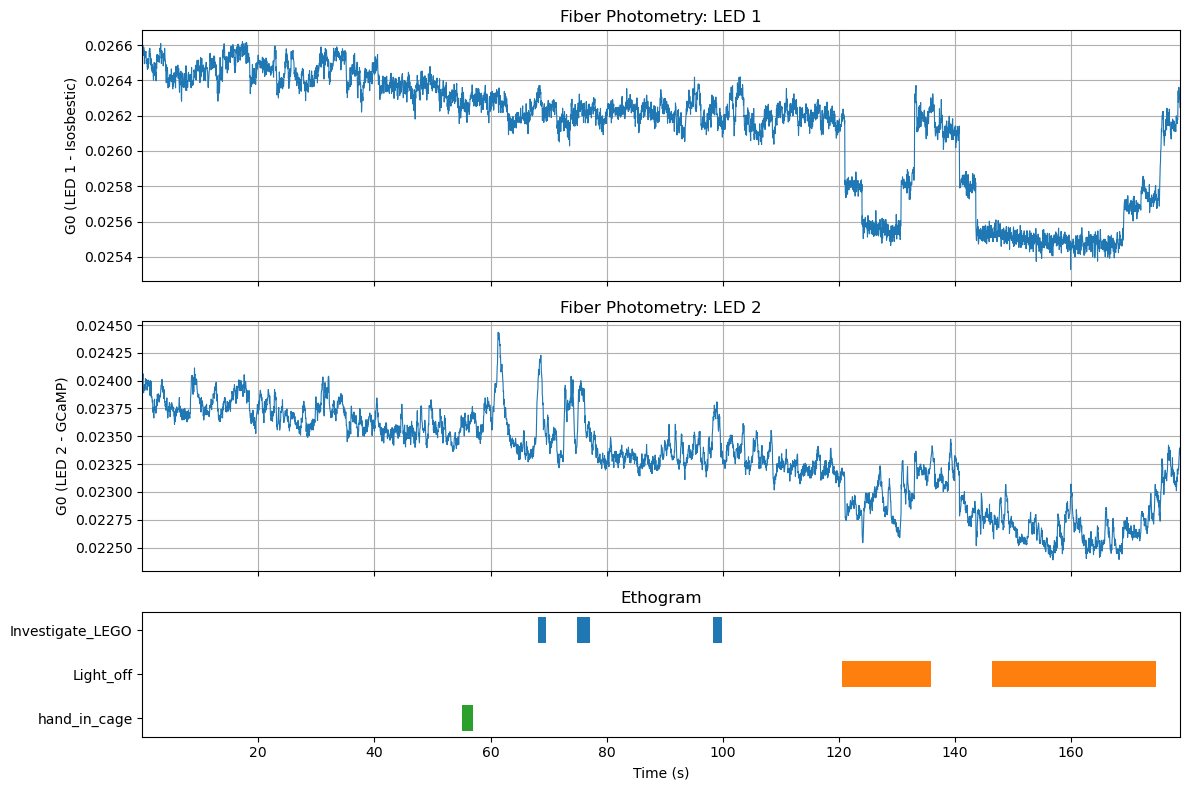

In [1]:
# Trial 6

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Trial11/OFT_FP6.csv"
ts_path = "Trial11/timestamp0.csv"
eth_path = "Trial11/Raw data-OFT_photobleaching_cohort2_20260204-Trial    11.xlsx"


behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage"
]

video_fps = 50.0
fp_fps = 50.0

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)

fp = fp[fp["LedState"].isin([1, 2])].copy()
fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# # -------------------------------------------------
# # 3. Load timestamp alignment (SAFE start/stop)
# # -------------------------------------------------
# ts = pd.read_csv(ts_path)

# true_ts = ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"]
# false_ts = ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"]

# if true_ts.empty:
#     raise ValueError("No TRUE DigitalIOState found — cannot determine video start.")

# video_start = float(true_ts.iloc[0])

# if not false_ts.empty:
#     video_stop = float(false_ts.iloc[0])
# else:
#     # FP stopped before video → use last timestamp available
#     video_stop = float(ts["SystemTimestamp"].iloc[-1])
#     print("WARNING: No FALSE DigitalIOState found — using last timestamp as video stop.")

# # Trim FP data to match video window
# fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
# fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 3. Load timestamp alignment (VIDEO START ONLY)
# -------------------------------------------------
ts = pd.read_csv(ts_path)

true_ts = ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"]

if true_ts.empty:
    raise ValueError("No TRUE DigitalIOState found — cannot determine video start.")

# Video starts when TTL goes TRUE
video_start = float(true_ts.iloc[0])

# Video ends when FP ends (FP stopped early)
video_stop = float(fp["SystemTimestamp"].max())

print(f"Video window used: {video_start:.3f} → {video_stop:.3f}")

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"] >= video_start].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start



# -------------------------------------------------
# 4. Load EthoVision data (header row 39)
# -------------------------------------------------
eth = pd.read_excel(eth_path, header=38)
eth = eth.dropna(axis=1, how="all")

# Identify time column
time_col = next((c for c in eth.columns if "Time" in str(c)), None)

if time_col is None:
    eth["Time_s"] = np.arange(len(eth)) / video_fps
else:
    eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# Keep only behaviors that exist
beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
if not beh_cols:
    print("Available columns:", list(eth.columns))
    raise ValueError("None of the specified behavior columns found in EthoVision data.")

eth = eth[["Time_s"] + beh_cols].copy()

# -------------------------------------------------
# 5. Prepare ethogram data for plotting
# -------------------------------------------------
segments = []

for beh in beh_cols:
    mask = eth[beh] == 1
    if mask.sum() == 0:
        continue

    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"].values
    ends = eth.loc[diff == -1, "Time_s"].values

    if mask.iloc[0]:
        starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
    if mask.iloc[-1]:
        ends = np.append(ends, eth["Time_s"].iloc[-1])

    for s, e in zip(starts, ends):
        segments.append({
            "Behavior": beh,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

timeline = (
    pd.DataFrame(segments)
    .sort_values(["Behavior", "Start_time_s"])
    .reset_index(drop=True)
)

# -------------------------------------------------
# 6. Plot FP traces + ethogram
# -------------------------------------------------
fig, axes = plt.subplots(
    3, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"height_ratios": [2, 2, 1]}
)

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1["G0"], linewidth=0.8)
axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2["G0"], linewidth=0.8)
axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
axes[1].set_title("Fiber Photometry: LED 2")
axes[1].grid(True)

# --- Ethogram ---
if not timeline.empty:
    behaviors = timeline["Behavior"].unique()
    colors = plt.cm.tab10.colors

    for i, beh in enumerate(behaviors):
        sub = timeline[timeline["Behavior"] == beh]
        for _, row in sub.iterrows():
            axes[2].barh(
                i,
                width=row["Duration_s"],
                left=row["Start_time_s"],
                height=0.6,
                color=colors[i % len(colors)]
            )

    axes[2].set_yticks(range(len(behaviors)))
    axes[2].set_yticklabels(behaviors)
    axes[2].invert_yaxis()
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Ethogram")

# --- Shared settings ---
axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()


In [ ]:
# # Trial 5

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # -------------------------------------------------
# # 1. File paths and parameters
# # -------------------------------------------------
# fp_path = "Trial11/OFT_FP6.csv"
# ts_path = "Trial11/timestamp0.csv"
# eth_path = "Trial11/Raw data-OFT_photobleaching_cohort2_20260204-Trial    11.xlsx"

# behaviors_of_interest = [
#     "Investigate_LEGO",
#     "Investigate_cheerio",
#     "Light_off",
#     "Lift_out_of_cage",
#     "hand_in_cage",
#     "smell-poop",
#     "Hand_touch_mouse"
# ]

# video_fps = 50.0  # EthoVision video frame rate
# fp_fps = 50.0     # Fiber photometry overall rate (25 Hz per LED)

# # -------------------------------------------------
# # 2. Load and clean fiber photometry data
# # -------------------------------------------------
# fp = pd.read_csv(fp_path)
# # Keep LED 1 and 2 only
# fp = fp[fp["LedState"].isin([1, 2])].copy()
# # Normalize time to start at 0
# fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# # -------------------------------------------------
# # 3. Load timestamp alignment (video start/stop)
# # -------------------------------------------------
# ts = pd.read_csv(ts_path)
# video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])
# video_stop  = float(ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"].iloc[0])

# # Trim FP data to match video window
# fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
# fp["Time_video"] = fp["SystemTimestamp"] - video_start

# # -------------------------------------------------
# # 4. Load EthoVision data (header row 39)
# # -------------------------------------------------
# eth = pd.read_excel(eth_path, header=38)
# eth = eth.dropna(axis=1, how="all")

# # Identify the time column
# time_col = next((c for c in eth.columns if "Time" in str(c)), None)
# if time_col is None:
#     eth["Time_s"] = np.arange(len(eth)) / video_fps
#     time_col = "Time_s"
# else:
#     eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# # Keep only specified behaviors that exist
# beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
# if not beh_cols:
#     print("Available columns:", list(eth.columns))
#     raise ValueError("None of the specified behavior columns found in EthoVision data!")

# eth = eth[["Time_s"] + beh_cols].copy()

# # -------------------------------------------------
# # 5. Prepare ethogram data for plotting
# # -------------------------------------------------
# segments = []
# for beh in beh_cols:
#     mask = eth[beh] == 1
#     if mask.sum() == 0:
#         continue
#     diff = mask.astype(int).diff().fillna(0)
#     starts = eth.loc[diff == 1, "Time_s"].values
#     ends = eth.loc[diff == -1, "Time_s"].values
#     if mask.iloc[0]:
#         starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
#     if mask.iloc[-1]:
#         ends = np.append(ends, eth["Time_s"].iloc[-1])
#     for s, e in zip(starts, ends):
#         segments.append({
#             "Behavior": beh,
#             "Start_time_s": float(s),
#             "End_time_s": float(e),
#             "Duration_s": float(e - s)
#         })

# timeline = pd.DataFrame(segments).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

# # -------------------------------------------------
# # 6. Plot FP traces (LED 1 & 2 separately) + ethogram
# # -------------------------------------------------
# fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
#                          gridspec_kw={"height_ratios": [2, 2, 1]})

# # --- LED 1 (isosbestic) ---
# fp1 = fp[fp["LedState"] == 1]
# axes[0].plot(fp1["Time_video"], fp1["G0"], color="tab:gray", linewidth=0.8)
# axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
# axes[0].set_title("Fiber Photometry: LED 1 (isosbestic)")
# axes[0].grid(True)

# # --- LED 2 (GCaMP) ---
# fp2 = fp[fp["LedState"] == 2]
# axes[1].plot(fp2["Time_video"], fp2["G0"], color="tab:green", linewidth=0.8)
# axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
# axes[1].set_title("Fiber Photometry: LED 2 (GCaMP)")
# axes[1].grid(True)

# # --- Ethogram (behaviors) ---
# if not timeline.empty:
#     behaviors = timeline["Behavior"].unique()
#     colors = plt.cm.tab10.colors
#     for i, beh in enumerate(behaviors):
#         sub = timeline[timeline["Behavior"] == beh]
#         for _, row in sub.iterrows():
#             axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"],
#                          color=colors[i % len(colors)], height=0.6)
#     axes[2].set_yticks(range(len(behaviors)))
#     axes[2].set_yticklabels(behaviors)
#     axes[2].set_xlabel("Time (s)")
#     axes[2].set_title("Ethogram (Behavior Occurrence)")
#     axes[2].invert_yaxis()

# # --- Shared settings ---
# axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
# plt.tight_layout()
# plt.show()


In [ ]:
# #photo bleaching correction

# # photobleaching correction

# # 1) Fit isosbestic with biexponential decay

# # --- Isosbestic 415: plot + biexponential (MATLAB 'exp2') ---
# from scipy.optimize import curve_fit

# # MATLAB: exp2 -> a*exp(b*x) + c*exp(d*x)
# def exp2(x, a, b, c, d):
#     return a * np.exp(b * x) + c * np.exp(d * x)

# # Select 415 / isosbestic samples (change to == 2 if needed)
# fp415 = fp[fp["LedState"] == 1].copy().sort_values("Time_video")

# # y = raw signal; temp_x = frame-index to mimic MATLAB's 'temp_x'
# y = fp415["G0"].to_numpy()
# temp_x = np.arange(y.size, dtype=float)

# # Fit biexponential to 415 using frame-index (robust initial guesses)
# p0 = [y.ptp(), -1e-3, 0.5 * y.ptp(), -1e-4]
# popt, _ = curve_fit(exp2, temp_x, y, p0=p0, maxfev=20000)

# # Evaluate fit at the same indices, plot against time for readability
# y_fit = exp2(temp_x, *popt)

# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp415["Time_video"], y, linewidth=0.8, label="415 (isosbestic) raw")
# ax.plot(fp415["Time_video"], y_fit, linewidth=1.2, label="biexponential fit (exp2)")
# ax.set_title("Isosbestic 415 with biexponential fit")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("G0")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()
# #
# #
# # 2) Linearly scale that fit to the calcium dependent data (using Robust Fit)

# from sklearn.linear_model import HuberRegressor  # robust linear regression

# # -------------------------------------------------
# # Assume you already have from previous step:
# #   fp415      -> dataframe with LedState == 1 (isosbestic)
# #   temp_x     -> np.arange(...) used for fitting
# #   popt       -> fitted parameters from exp2
# # -------------------------------------------------

# # --- Get the calcium-dependent 470 channel ---
# fp470 = fp[fp["LedState"] == 2].copy().sort_values("Time_video")

# # Make sure the two have the same length or align by time if needed
# # (Here we simply interpolate the 415 fit to 470 sample times.)
# from scipy.interpolate import interp1d
# fit_func = lambda x: popt[0]*np.exp(popt[1]*x) + popt[2]*np.exp(popt[3]*x)

# # Map time to frame index (same as before)
# idx_from_time = interp1d(fp415["Time_video"], temp_x, kind="linear",
#                          fill_value="extrapolate", assume_sorted=True)
# x470_idx = idx_from_time(fp470["Time_video"])
# iso_fit_at_470 = fit_func(x470_idx)

# # --- Robust linear scaling: equivalent of MATLAB robustfit(...,'bisquare') ---
# huber = HuberRegressor()  # similar spirit to robustfit
# huber.fit(iso_fit_at_470.reshape(-1, 1), fp470["G0"].to_numpy())

# slope = float(huber.coef_[0])
# intercept = float(huber.intercept_)

# # MATLAB: FP.lin_fit = FP.fit1(temp_x)*FP.fit2(2)+FP.fit2(1)
# fp470["lin_fit"] = intercept + slope * iso_fit_at_470

# # --- Plot raw 470 and scaled isosbestic fit ---
# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp470["Time_video"], fp470["G0"], linewidth=0.8, label="470 nm raw (Ca-dependent)")
# ax.plot(fp470["Time_video"], fp470["lin_fit"], linewidth=1.2, label="Scaled 415 nm fit (robust)")
# ax.set_title("Scaled isosbestic fit to calcium-dependent 470 nm signal")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("G0")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()

# #3) Divide your raw 470 data by the scaled fit (dF)

# # -------------------------------------------------
# # 3) Divide raw 470 data by the scaled fit (dF)
# # MATLAB:
# #   FP.data(:,4) = FP.data(:,2) ./ FP.lin_fit;
# #   plot(FP.data(:,4))
# # -------------------------------------------------

# # Compute normalized fluorescence (dF)
# fp470["dF"] = fp470["G0"] / fp470["lin_fit"]

# # --- Plot normalized F value ---
# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp470["Time_video"], fp470["dF"], linewidth=0.8, label="Normalized F (dF)")
# ax.set_title("Normalized 470 nm signal (dF = raw / scaled fit)")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("Normalized Fluorescence (a.u.)")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()

# #4) Calculate dF/F (%)

# # -------------------------------------------------
# # 4) Calculate dF/F (%) 
# # MATLAB:
# #   FP.data(:,5) = 100 * (FP.data(:,2) - FP.lin_fit) ./ FP.lin_fit;
# #   plot(FP.data(:,5))
# # -------------------------------------------------

# # Compute dF/F (%) — relative fluorescence change
# fp470["dF_F_percent"] = 100 * (fp470["G0"] - fp470["lin_fit"]) / fp470["lin_fit"]

# # --- Plot dF/F (%) ---
# fig, ax = plt.subplots(1, 1, figsize=(12, 3))
# ax.plot(fp470["Time_video"], fp470["dF_F_percent"], linewidth=0.8, label="dF/F (%)")
# ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
# ax.set_title("ΔF/F (%) — scaled relative fluorescence")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("ΔF/F (%)")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()



In [ ]:
# # -------------------------------------------------
# # Peri-Event Plot for 'Investigate_LEGO' with colored traces
# # -------------------------------------------------
# import numpy as np
# import matplotlib.pyplot as plt

# # --- Parameters ---
# bl = 100            # samples before event (~2 s at 50 Hz)
# seg_dur = 200       # samples after event (~4 s)
# signal_col = "dF_F_percent"   # which signal to use

# # --- Effective frame rate ---
# fps = 1 / np.mean(np.diff(fp470["Time_video"]))
# print(f"Effective frame rate ≈ {fps:.2f} Hz")

# # --- Get timestamps for 'Investigate_LEGO' starts ---
# mask = eth["Investigate_LEGO"] == 1
# diffs = mask.astype(int).diff().fillna(0)
# starts = eth.loc[diffs == 1, "Time_s"].to_numpy()

# # --- Collect peri-event segments ---
# segments = []
# signal = fp470[signal_col].to_numpy()
# time_fp = fp470["Time_video"].to_numpy()

# for ev_time in starts:
#     temp_idx = np.searchsorted(time_fp, ev_time)
#     if temp_idx >= bl and (temp_idx + seg_dur) < len(signal):
#         seg = signal[temp_idx - bl : temp_idx + seg_dur]
#         seg = seg - np.mean(seg[:bl])  # baseline correction
#         segments.append(seg)

# if len(segments) == 0:
#     raise ValueError("No valid LEGO events found within boundaries.")

# ERF = np.column_stack(segments)
# ERF_time = np.linspace(-bl/fps, seg_dur/fps, ERF.shape[0])

# # --- Plot ---
# fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# # Colored individual traces (muted)
# colors = plt.cm.tab10(np.linspace(0, 1, ERF.shape[1]))
# for i, col in enumerate(colors):
#     ax.plot(ERF_time, ERF[:, i], color=col, alpha=0.3, linewidth=1)

# # Thick black mean trace
# ax.plot(ERF_time, np.mean(ERF, axis=1), color="black", linewidth=2.5, label="Mean")

# # Formatting
# ax.axvline(0, color="k", linestyle="--", linewidth=1)
# ax.set_title("Peri-Event Fluorescence (Investigate_LEGO)")
# ax.set_xlabel("Time Relative to Event Start (s)")
# ax.set_ylabel("ΔF/F (%), baseline-corrected")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()


In [ ]:
# # -------------------------------------------------
# # Peri-Event Plot for 'Investigate_cheerio'
# # -------------------------------------------------
# import numpy as np
# import matplotlib.pyplot as plt

# # --- Parameters ---
# bl = 100            # samples before event (~2 s at 50 Hz)
# seg_dur = 200       # samples after event (~4 s)
# signal_col = "dF_F_percent"   # which signal to use for peri-event analysis

# # --- Effective frame rate ---
# fps = 1 / np.mean(np.diff(fp470["Time_video"]))
# print(f"Effective frame rate ≈ {fps:.2f} Hz")

# # --- Get timestamps for 'Investigate_cheerio' starts ---
# mask = eth["Investigate_cheerio"] == 1
# diffs = mask.astype(int).diff().fillna(0)
# starts = eth.loc[diffs == 1, "Time_s"].to_numpy()

# # --- Collect peri-event segments ---
# segments = []
# signal = fp470[signal_col].to_numpy()
# time_fp = fp470["Time_video"].to_numpy()

# for ev_time in starts:
#     temp_idx = np.searchsorted(time_fp, ev_time)
#     if temp_idx >= bl and (temp_idx + seg_dur) < len(signal):
#         seg = signal[temp_idx - bl : temp_idx + seg_dur]
#         seg = seg - np.mean(seg[:bl])  # baseline correction
#         segments.append(seg)

# if len(segments) == 0:
#     raise ValueError("No valid 'Investigate_cheerio' events found within boundaries.")

# ERF = np.column_stack(segments)
# ERF_time = np.linspace(-bl/fps, seg_dur/fps, ERF.shape[0])

# # --- Plot ---
# fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# # Colored individual traces (distinct but faint)
# colors = plt.cm.tab10(np.linspace(0, 1, ERF.shape[1]))
# for i, col in enumerate(colors):
#     ax.plot(ERF_time, ERF[:, i], color=col, alpha=0.3, linewidth=1)

# # Thick black mean trace
# ax.plot(ERF_time, np.mean(ERF, axis=1), color="black", linewidth=2.5, label="Mean")

# # Formatting
# ax.axvline(0, color="k", linestyle="--", linewidth=1)
# ax.set_title("Peri-Event Fluorescence (Investigate_cheerio)")
# ax.set_xlabel("Time Relative to Event Start (s)")
# ax.set_ylabel("ΔF/F (%), baseline-corrected")
# ax.grid(True)
# ax.legend(frameon=False)
# plt.tight_layout()
# plt.show()


In [ ]:
# # Trial 6

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # -------------------------------------------------
# # 1. File paths and parameters
# # -------------------------------------------------
# fp_path = "Trial15/OFT_FP10.csv"
# ts_path = "Trial15/timestamp0.csv"
# eth_path = "Trial15/Raw data-OFT_photobleaching_cohort2_20260204-Trial    15.xlsx"

# behaviors_of_interest = [
#     "Investigate_LEGO",
#     "Investigate_cheerio",
#     "Light_off",
#     "Lift_out_of_cage",
#     "hand_in_cage",
#     "smell-poop",
#     "Hand_touch_mouse"
# ]

# video_fps = 50.0  # EthoVision video frame rate
# fp_fps = 50.0     # Fiber photometry overall rate (25 Hz per LED)

# # -------------------------------------------------
# # 2. Load and clean fiber photometry data
# # -------------------------------------------------
# fp = pd.read_csv(fp_path)
# # Keep LED 1 and 2 only
# fp = fp[fp["LedState"].isin([1, 2])].copy()
# # Normalize time to start at 0
# fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# # -------------------------------------------------
# # 3. Load timestamp alignment (video start/stop)
# # -------------------------------------------------
# ts = pd.read_csv(ts_path)
# video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])
# video_stop  = float(ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"].iloc[0])

# # Trim FP data to match video window
# fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
# fp["Time_video"] = fp["SystemTimestamp"] - video_start

# # -------------------------------------------------
# # 4. Load EthoVision data (header row 39)
# # -------------------------------------------------
# eth = pd.read_excel(eth_path, header=38)
# eth = eth.dropna(axis=1, how="all")

# # Identify the time column
# time_col = next((c for c in eth.columns if "Time" in str(c)), None)
# if time_col is None:
#     eth["Time_s"] = np.arange(len(eth)) / video_fps
#     time_col = "Time_s"
# else:
#     eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# # Keep only specified behaviors that exist
# beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
# if not beh_cols:
#     print("Available columns:", list(eth.columns))
#     raise ValueError("None of the specified behavior columns found in EthoVision data!")

# eth = eth[["Time_s"] + beh_cols].copy()

# # -------------------------------------------------
# # 5. Prepare ethogram data for plotting
# # -------------------------------------------------
# segments = []
# for beh in beh_cols:
#     mask = eth[beh] == 1
#     if mask.sum() == 0:
#         continue
#     diff = mask.astype(int).diff().fillna(0)
#     starts = eth.loc[diff == 1, "Time_s"].values
#     ends = eth.loc[diff == -1, "Time_s"].values
#     if mask.iloc[0]:
#         starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
#     if mask.iloc[-1]:
#         ends = np.append(ends, eth["Time_s"].iloc[-1])
#     for s, e in zip(starts, ends):
#         segments.append({
#             "Behavior": beh,
#             "Start_time_s": float(s),
#             "End_time_s": float(e),
#             "Duration_s": float(e - s)
#         })

# timeline = pd.DataFrame(segments).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

# # -------------------------------------------------
# # 6. Plot FP traces (LED 1 & 2 separately) + ethogram
# # -------------------------------------------------
# fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
#                          gridspec_kw={"height_ratios": [2, 2, 1]})

# # --- LED 1 (isosbestic) ---
# fp1 = fp[fp["LedState"] == 1]
# axes[0].plot(fp1["Time_video"], fp1["G0"], color="tab:gray", linewidth=0.8)
# axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
# axes[0].set_title("Fiber Photometry: LED 1 (isosbestic)")
# axes[0].grid(True)

# # --- LED 2 (GCaMP) ---
# fp2 = fp[fp["LedState"] == 2]
# axes[1].plot(fp2["Time_video"], fp2["G0"], color="tab:green", linewidth=0.8)
# axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
# axes[1].set_title("Fiber Photometry: LED 2 (GCaMP)")
# axes[1].grid(True)

# # --- Ethogram (behaviors) ---
# if not timeline.empty:
#     behaviors = timeline["Behavior"].unique()
#     colors = plt.cm.tab10.colors
#     for i, beh in enumerate(behaviors):
#         sub = timeline[timeline["Behavior"] == beh]
#         for _, row in sub.iterrows():
#             axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"],
#                          color=colors[i % len(colors)], height=0.6)
#     axes[2].set_yticks(range(len(behaviors)))
#     axes[2].set_yticklabels(behaviors)
#     axes[2].set_xlabel("Time (s)")
#     axes[2].set_title("Ethogram (Behavior Occurrence)")
#     axes[2].invert_yaxis()

# # --- Shared settings ---
# axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
# plt.tight_layout()
# plt.show()


In [ ]:
# Trial 6

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Trial15/OFT_FP10.csv"
ts_path = "Trial15/timestamp0.csv"
eth_path = "Trial15/Raw data-OFT_photobleaching_cohort2_20260204-Trial    15.xlsx"

behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage"
]

video_fps = 50.0
fp_fps = 50.0

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)

fp = fp[fp["LedState"].isin([1, 2])].copy()
fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# # -------------------------------------------------
# # 3. Load timestamp alignment (SAFE start/stop)
# # -------------------------------------------------
# ts = pd.read_csv(ts_path)

# true_ts = ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"]
# false_ts = ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"]

# if true_ts.empty:
#     raise ValueError("No TRUE DigitalIOState found — cannot determine video start.")

# video_start = float(true_ts.iloc[0])

# if not false_ts.empty:
#     video_stop = float(false_ts.iloc[0])
# else:
#     # FP stopped before video → use last timestamp available
#     video_stop = float(ts["SystemTimestamp"].iloc[-1])
#     print("WARNING: No FALSE DigitalIOState found — using last timestamp as video stop.")

# # Trim FP data to match video window
# fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
# fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 3. Load timestamp alignment (VIDEO START ONLY)
# -------------------------------------------------
ts = pd.read_csv(ts_path)

true_ts = ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"]

if true_ts.empty:
    raise ValueError("No TRUE DigitalIOState found — cannot determine video start.")

# Video starts when TTL goes TRUE
video_start = float(true_ts.iloc[0])

# Video ends when FP ends (FP stopped early)
video_stop = float(fp["SystemTimestamp"].max())

print(f"Video window used: {video_start:.3f} → {video_stop:.3f}")

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"] >= video_start].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start



# -------------------------------------------------
# 4. Load EthoVision data (header row 39)
# -------------------------------------------------
eth = pd.read_excel(eth_path, header=38)
eth = eth.dropna(axis=1, how="all")

# Identify time column
time_col = next((c for c in eth.columns if "Time" in str(c)), None)

if time_col is None:
    eth["Time_s"] = np.arange(len(eth)) / video_fps
else:
    eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# Keep only behaviors that exist
beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
if not beh_cols:
    print("Available columns:", list(eth.columns))
    raise ValueError("None of the specified behavior columns found in EthoVision data.")

eth = eth[["Time_s"] + beh_cols].copy()

# -------------------------------------------------
# 5. Prepare ethogram data for plotting
# -------------------------------------------------
segments = []

for beh in beh_cols:
    mask = eth[beh] == 1
    if mask.sum() == 0:
        continue

    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"].values
    ends = eth.loc[diff == -1, "Time_s"].values

    if mask.iloc[0]:
        starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
    if mask.iloc[-1]:
        ends = np.append(ends, eth["Time_s"].iloc[-1])

    for s, e in zip(starts, ends):
        segments.append({
            "Behavior": beh,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

timeline = (
    pd.DataFrame(segments)
    .sort_values(["Behavior", "Start_time_s"])
    .reset_index(drop=True)
)

# -------------------------------------------------
# 6. Plot FP traces + ethogram
# -------------------------------------------------
fig, axes = plt.subplots(
    3, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"height_ratios": [2, 2, 1]}
)

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1["G0"], linewidth=0.8)
axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2["G0"], linewidth=0.8)
axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
axes[1].set_title("Fiber Photometry: LED 2")
axes[1].grid(True)

# --- Ethogram ---
if not timeline.empty:
    behaviors = timeline["Behavior"].unique()
    colors = plt.cm.tab10.colors

    for i, beh in enumerate(behaviors):
        sub = timeline[timeline["Behavior"] == beh]
        for _, row in sub.iterrows():
            axes[2].barh(
                i,
                width=row["Duration_s"],
                left=row["Start_time_s"],
                height=0.6,
                color=colors[i % len(colors)]
            )

    axes[2].set_yticks(range(len(behaviors)))
    axes[2].set_yticklabels(behaviors)
    axes[2].invert_yaxis()
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Ethogram")

# --- Shared settings ---
axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()


In [ ]:
# Trial 6

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Trial16/OFT_FP11.csv"
ts_path = "Trial16/timestamp0.csv"
eth_path = "Trial16/Raw data-OFT_photobleaching_cohort2_20260204-Trial    16.xlsx"

behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage"
]

video_fps = 50.0
fp_fps = 50.0

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)

fp = fp[fp["LedState"].isin([1, 2])].copy()
fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# # -------------------------------------------------
# # 3. Load timestamp alignment (SAFE start/stop)
# # -------------------------------------------------
# ts = pd.read_csv(ts_path)

# true_ts = ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"]
# false_ts = ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"]

# if true_ts.empty:
#     raise ValueError("No TRUE DigitalIOState found — cannot determine video start.")

# video_start = float(true_ts.iloc[0])

# if not false_ts.empty:
#     video_stop = float(false_ts.iloc[0])
# else:
#     # FP stopped before video → use last timestamp available
#     video_stop = float(ts["SystemTimestamp"].iloc[-1])
#     print("WARNING: No FALSE DigitalIOState found — using last timestamp as video stop.")

# # Trim FP data to match video window
# fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
# fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 3. Load timestamp alignment (VIDEO START ONLY)
# -------------------------------------------------
ts = pd.read_csv(ts_path)

true_ts = ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"]

if true_ts.empty:
    raise ValueError("No TRUE DigitalIOState found — cannot determine video start.")

# Video starts when TTL goes TRUE
video_start = float(true_ts.iloc[0])

# Video ends when FP ends (FP stopped early)
video_stop = float(fp["SystemTimestamp"].max())

print(f"Video window used: {video_start:.3f} → {video_stop:.3f}")

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"] >= video_start].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start



# -------------------------------------------------
# 4. Load EthoVision data (header row 39)
# -------------------------------------------------
eth = pd.read_excel(eth_path, header=38)
eth = eth.dropna(axis=1, how="all")

# Identify time column
time_col = next((c for c in eth.columns if "Time" in str(c)), None)

if time_col is None:
    eth["Time_s"] = np.arange(len(eth)) / video_fps
else:
    eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# Keep only behaviors that exist
beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
if not beh_cols:
    print("Available columns:", list(eth.columns))
    raise ValueError("None of the specified behavior columns found in EthoVision data.")

eth = eth[["Time_s"] + beh_cols].copy()

# -------------------------------------------------
# 5. Prepare ethogram data for plotting
# -------------------------------------------------
segments = []

for beh in beh_cols:
    mask = eth[beh] == 1
    if mask.sum() == 0:
        continue

    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"].values
    ends = eth.loc[diff == -1, "Time_s"].values

    if mask.iloc[0]:
        starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
    if mask.iloc[-1]:
        ends = np.append(ends, eth["Time_s"].iloc[-1])

    for s, e in zip(starts, ends):
        segments.append({
            "Behavior": beh,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

timeline = (
    pd.DataFrame(segments)
    .sort_values(["Behavior", "Start_time_s"])
    .reset_index(drop=True)
)

# -------------------------------------------------
# 6. Plot FP traces + ethogram
# -------------------------------------------------
fig, axes = plt.subplots(
    3, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"height_ratios": [2, 2, 1]}
)

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1["G0"], linewidth=0.8)
axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2["G0"], linewidth=0.8)
axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
axes[1].set_title("Fiber Photometry: LED 2")
axes[1].grid(True)

# --- Ethogram ---
if not timeline.empty:
    behaviors = timeline["Behavior"].unique()
    colors = plt.cm.tab10.colors

    for i, beh in enumerate(behaviors):
        sub = timeline[timeline["Behavior"] == beh]
        for _, row in sub.iterrows():
            axes[2].barh(
                i,
                width=row["Duration_s"],
                left=row["Start_time_s"],
                height=0.6,
                color=colors[i % len(colors)]
            )

    axes[2].set_yticks(range(len(behaviors)))
    axes[2].set_yticklabels(behaviors)
    axes[2].invert_yaxis()
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Ethogram")

# --- Shared settings ---
axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()
